# PyTorch U-Net: Retinal Blood Vessel Segmentation

### Introduction
In this notebook, we build a U-Net architecture from scratch using PyTorch to perform highly precise semantic segmentation. Using the DRIVE (Digital Retinal Images for Vessel Extraction) dataset, we train a fully convolutional network to automatically map and extract the complex network of blood vessels from raw photographs of the human eye. 

### Table of Contents
* **Understanding the Data**
* **Building the Custom PyTorch Dataset**
* **Data Visualization & Sanity Check**
* **Constructing the U-Net Architecture**
* **The Training Pipeline (Loss & Optimizer)**
* **Evaluating Model Predictions**
* **Production Inference (Testing on Unseen Data)**
* **Saving the Model Weights**





## Understanding the Data
The DRIVE dataset consists of `.tif` images (the retinal photos) and `.gif` masks (the ground-truth blood vessels). Standard data loaders struggle with these mixed formats, requiring a custom pipeline.

## Building the Custom PyTorch Datase
The DRIVE dataset consists of `.tif` images (the retinal photos) and `.gif` masks (the ground-truth blood vessels). 

Standard data loaders struggle with these formats, so we are building a custom PyTorch `Dataset` class. This class will:
1. Load the images and masks using `PIL` (which handles `.gif` perfectly).
2. Resize both to $512 \times 512$ pixels. (U-Net requires dimensions divisible by 16 or 32 for its downsampling/upsampling architecture).
3. Convert the data into PyTorch Tensors with a shape of `[Channels, Height, Width]`.
4. Binarize the masks so every pixel is strictly `0` (background) or `1` (blood vessel).

In [2]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from glob import glob

class DriveDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        
        # Define the exact transformations
        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor() # Converts to Tensor and scales pixels to [0, 1]
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Load the image and mask
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L") # "L" converts to Grayscale
        
        # 2. Apply transformations
        image = self.transform(image)
        mask = self.transform(mask)
        
        # 3. Ensure mask is strictly binary (0 or 1)
        mask = (mask > 0.5).float()
        
        return image, mask

print(" Custom PyTorch Dataset Class created successfully!")

 Custom PyTorch Dataset Class created successfully!


## Data Visualization & Sanity Check

Datasets in Linux environments (like Kaggle) are strictly case-sensitive. If an image is saved as `.TIF` instead of `.tif`, a standard file search will miss it entirely. 

To make this pipeline bulletproof, we use `os.walk()` to recursively hunt through every directory. 
1. **Dynamic Searching:** It finds every image and mask regardless of folder structure or hidden capitalization.
2. **Sorting:** We use `sorted()` to ensure the input images (`train_x`) and the ground-truth masks (`train_y`) line up perfectly by index.
3. **Sanity Check:** We pass the first matched pair into our custom `DriveDataset` and plot them side-by-side to verify the tensors are forming correctly before feeding them to the U-Net.

 Images successfully found: 20
 Masks successfully found: 20


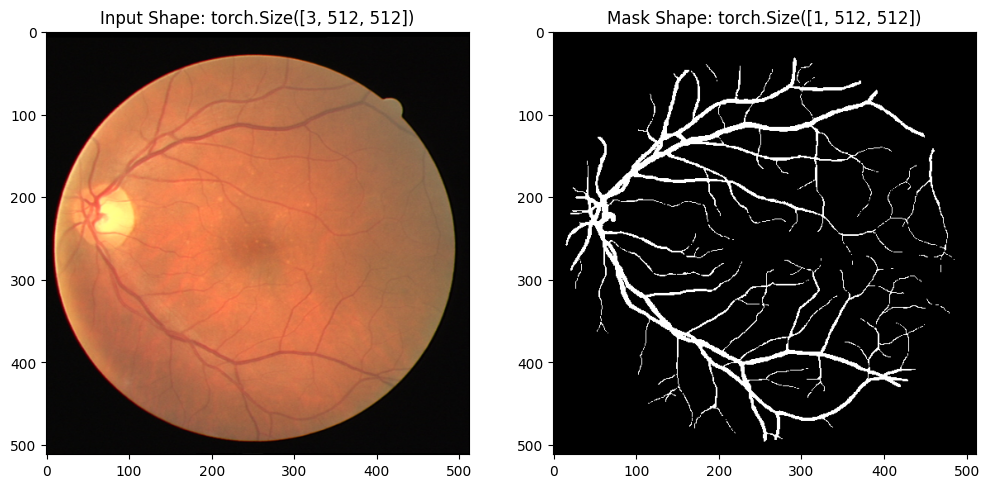

In [3]:
import os
import matplotlib.pyplot as plt

input_dir = '/kaggle/input/'

train_x = []
train_y = []

# 1. Hunt down the exact file paths dynamically
for root, dirs, files in os.walk(input_dir):
    for file in files:
        # Grab the images (ignoring case sensitivity)
        if file.lower().endswith(('.tif', '.png', '.jpg')) and 'training' in root and 'images' in root:
            train_x.append(os.path.join(root, file))
        # Grab the masks (ignoring case sensitivity)
        elif file.lower().endswith(('.gif', '.png', '.tif')) and 'training' in root and '1st_manual' in root:
            train_y.append(os.path.join(root, file))

# 2. Sort them so the images and masks line up perfectly
train_x = sorted(train_x)
train_y = sorted(train_y)

print(f" Images successfully found: {len(train_x)}")
print(f" Masks successfully found: {len(train_y)}")

# 3. If we found them, plot the first one!
if len(train_x) > 0:
    # Instantiate the dataset we built in Step 4
    # (Make sure you ran the Step 4 code cell before running this one!)
    train_dataset = DriveDataset(train_x, train_y)
    
    # Grab the very first image and mask
    image, mask = train_dataset[0]
    
    # Format them for Matplotlib
    image_np = image.permute(1, 2, 0).numpy()
    mask_np = mask.squeeze().numpy()
    
    # Plot!
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title(f"Input Shape: {image.shape}")
    plt.imshow(image_np)
    
    plt.subplot(1, 2, 2)
    plt.title(f"Mask Shape: {mask.shape}")
    plt.imshow(mask_np, cmap='gray')
    plt.show()
else:
    print(" Still missing! Check if the dataset finished downloading to the notebook.")

## Constructing the U-Net Architecture

We are building the standard U-Net architecture. Here is how the PyTorch class is structured:
1. **DoubleConv Block:** A helper class that runs two $3 \times 3$ Convolutions, each followed by Batch Normalization and a ReLU activation. We use `padding=1` so the image dimensions don't shrink during convolution.
2. **Encoder (Downsampling):** Uses `MaxPool2d` to halve the spatial dimensions while doubling the feature channels.
3. **Bottleneck:** The bottom of the "U" where the model holds the most compressed feature representations.
4. **Decoder (Upsampling):** Uses `ConvTranspose2d` to double the spatial dimensions. 
5. **Skip Connections:** We use `torch.cat` to concatenate the high-resolution feature maps from the Encoder directly into the Decoder to give the model perfect pixel-level accuracy for the mask edges.
6. **Final Layer:** A $1 \times 1$ Convolution (`outconv`) that squashes the feature channels down to exactly 1 channel (our binary blood vessel mask).

In [4]:
import torch
import torch.nn as nn

# 1. Helper Class: The Double Convolution Block
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# 2. The Main U-Net Architecture
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        
        # --- ENCODER (Downsampling path) ---
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # --- BOTTLENECK ---
        self.bottleneck = DoubleConv(512, 1024)
        
        # --- DECODER (Upsampling path with Skip Connections) ---
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up4 = DoubleConv(1024, 512) # 512 from upconv + 512 from skip = 1024 total in!
        
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up3 = DoubleConv(512, 256)
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up2 = DoubleConv(256, 128)
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up1 = DoubleConv(128, 64)
        
        # --- FINAL LAYER ---
        # 1x1 Convolution to reduce channels to our desired number of classes (1 for binary mask)
        self.outconv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder passes
        d1 = self.down1(x)
        x = self.pool(d1)
        
        d2 = self.down2(x)
        x = self.pool(d2)
        
        d3 = self.down3(x)
        x = self.pool(d3)
        
        d4 = self.down4(x)
        x = self.pool(d4)
        
        # Bottleneck pass
        x = self.bottleneck(x)
        
        # Decoder passes (Upsample -> Concatenate -> DoubleConv)
        x = self.upconv4(x)
        x = torch.cat([x, d4], dim=1) # The Skip Connection!
        x = self.up4(x)
        
        x = self.upconv3(x)
        x = torch.cat([x, d3], dim=1)
        x = self.up3(x)
        
        x = self.upconv2(x)
        x = torch.cat([x, d2], dim=1)
        x = self.up2(x)
        
        x = self.upconv1(x)
        x = torch.cat([x, d1], dim=1)
        x = self.up1(x)
        
        # Final 1x1 Conv
        return self.outconv(x)

# --- THE SANITY CHECK ---
# Let's create a dummy image tensor matching our exact input dimensions: [Batch Size, Channels, Height, Width]
dummy_image = torch.randn(1, 3, 512, 512)

# Initialize the model
model = UNet(in_channels=3, out_channels=1)

# Pass the dummy image through the model
dummy_output = model(dummy_image)

print(f" U-Net Successfully Built!")
print(f"Input Shape: {dummy_image.shape}")
print(f"Output Shape: {dummy_output.shape}")

 U-Net Successfully Built!
Input Shape: torch.Size([1, 3, 512, 512])
Output Shape: torch.Size([1, 1, 512, 512])


## The Training Pipeline (Loss & Optimizer)

To train the model, we need three main components:
1. **DataLoaders:** We wrap our custom `Dataset` in a PyTorch `DataLoader`. This automatically groups our images into "batches" so we don't crash the GPU by trying to load all 20 images at once.
2. **The Loss Function:** We are using `BCEWithLogitsLoss` (Binary Cross Entropy). This is the absolute standard for binary segmentation. It compares the model's predicted pixel probabilities against the strict 0 or 1 values of the ground-truth mask.
3. **The Optimizer:** We use `Adam` with a standard learning rate of `1e-4` to update the model's weights after every batch.

In [5]:
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Create the DataLoader
# We use batch_size=2 because 512x512 images take up a lot of VRAM!
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

# 2. Setup Device, Model, Loss, and Optimizer
# This automatically pushes the heavy math to the Kaggle GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Training on device: {device}")

model = UNet(in_channels=3, out_channels=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 3. The Training Loop
num_epochs = 10 # Let's run 10 quick passes over the data

print("Starting the training engine...")

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss = 0
    
    for images, masks in train_loader:
        # Move data to the GPU
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass: Ask the model to guess the mask
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass: Calculate how to fix the mistakes
        optimizer.zero_grad() # Clear old gradients
        loss.backward()       # Compute new gradients
        optimizer.step()      # Update the weights
        
        epoch_loss += loss.item()
        
    # Print the average loss for this epoch
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print(" Training complete! The model has learned!")

 Training on device: cuda
Starting the training engine...
Epoch [1/10], Loss: 0.6733
Epoch [2/10], Loss: 0.5601
Epoch [3/10], Loss: 0.4927
Epoch [4/10], Loss: 0.4508
Epoch [5/10], Loss: 0.4334
Epoch [6/10], Loss: 0.4107
Epoch [7/10], Loss: 0.4059
Epoch [8/10], Loss: 0.3918
Epoch [9/10], Loss: 0.3796
Epoch [10/10], Loss: 0.3711
 Training complete! The model has learned!


## Evaluating Model Predictions

To see what our model learned, we need to extract its predictions and format them back into images. 
1. **`model.eval()`:** We switch the model out of training mode. This locks the weights so they don't change during our test.
2. **`torch.no_grad()`:** We turn off gradient tracking to save memory, since we aren't updating weights anymore.
3. **Sigmoid & Threshold:** Because our loss function was `BCEWithLogitsLoss`, the model outputs raw, unbounded numbers (logits). We must pass them through a `torch.sigmoid()` function to squash them between 0 and 1, and then threshold them at `0.5` to make strict black-and-white binary masks.

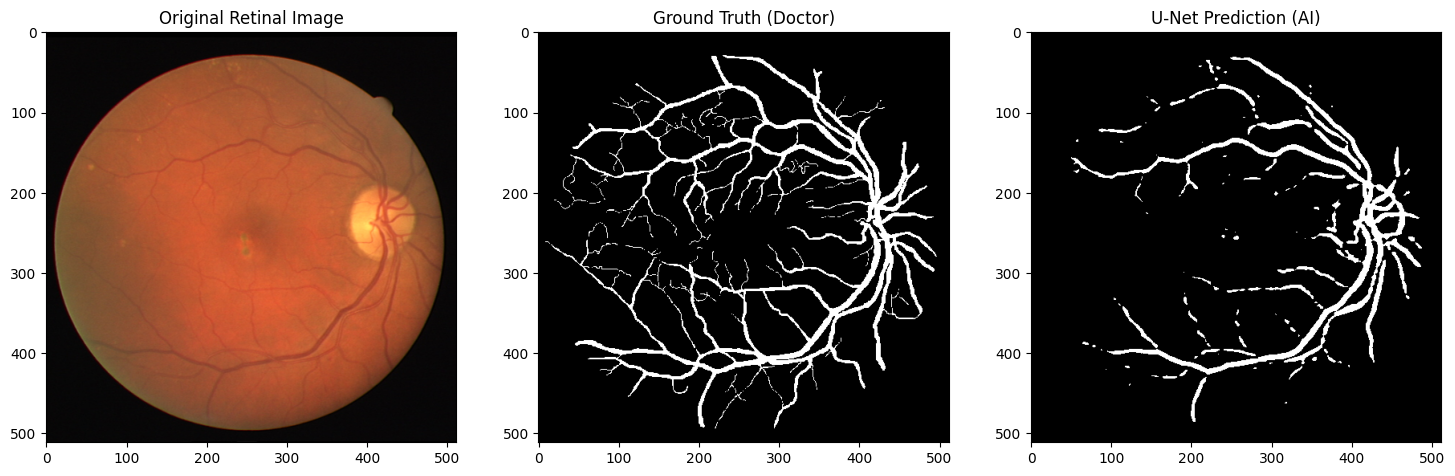

In [6]:
# 1. Lock the model for testing
model.eval()

# 2. Grab a single batch of images from our data loader
images, masks = next(iter(train_loader))

# Move the images to the GPU
images = images.to(device)

# 3. Make the prediction
with torch.no_grad():
    raw_predictions = model(images)
    
    # Squash the raw numbers into probabilities (0 to 1)
    probs = torch.sigmoid(raw_predictions)
    
    # Binarize the probabilities (Anything > 50% sure becomes a 1)
    binary_preds = (probs > 0.5).float()

# 4. Move data back to the CPU so Matplotlib can read it
# We grab the very first image in the batch (index 0)
original_img = images[0].cpu().permute(1, 2, 0).numpy()
ground_truth = masks[0].cpu().squeeze().numpy()
unet_pred = binary_preds[0].cpu().squeeze().numpy()

# 5. Plot the ultimate comparison!
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Original Retinal Image")
plt.imshow(original_img)

plt.subplot(1, 3, 2)
plt.title("Ground Truth (Doctor)")
plt.imshow(ground_truth, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("U-Net Prediction (AI)")
plt.imshow(unet_pred, cmap='gray')

plt.show()

## Production Inference (Testing on Unseen Data)

To prove our model isn't just memorizing the training data (overfitting), we must evaluate it on the Test Set. 
1. We dynamically locate the `test` folder paths using `os.walk`.
2. We load the unseen data into our custom `DriveDataset`.
3. We pass a completely new image through the locked model (`model.eval()`) and visualize the result. If the model successfully segments the vessels here, it has truly learned the underlying features of a retinal scan.

 Test Images found: 20


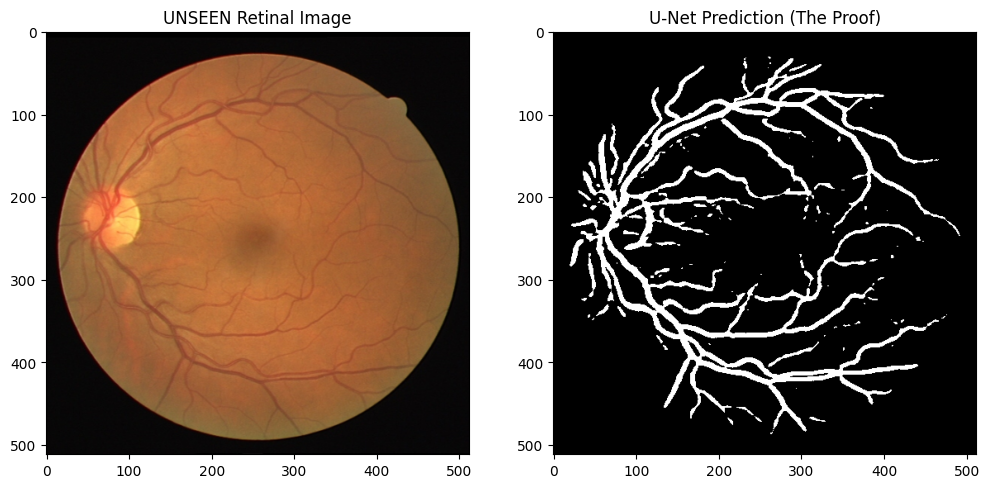

In [9]:
from PIL import Image
from torchvision import transforms

# 1. Hunt down JUST the test images
test_x = []
for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith(('.tif', '.png', '.jpg')) and 'test' in root and 'images' in root:
            test_x.append(os.path.join(root, file))

test_x = sorted(test_x)
print(f" Test Images found: {len(test_x)}")

if len(test_x) > 0:
    # 2. Production Inference: Load the image manually
    test_img_path = test_x[0]
    raw_img = Image.open(test_img_path).convert("RGB")
    
    # 3. Apply the exact same transformations we used in training
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor()
    ])
    
    # Transform it, add a batch dimension [1, C, H, W], and send to GPU
    input_tensor = transform(raw_img).unsqueeze(0).to(device) 
    
    # 4. Make the Prediction
    with torch.no_grad():
        raw_pred = model(input_tensor)
        prob_pred = torch.sigmoid(raw_pred)
        binary_pred = (prob_pred > 0.5).float()
        
    # 5. Format for Matplotlib
    display_img = input_tensor[0].cpu().permute(1, 2, 0).numpy()
    display_pred = binary_pred[0].cpu().squeeze().numpy()
    
    # 6. Plot the final proof!
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title("UNSEEN Retinal Image")
    plt.imshow(display_img)
    
    plt.subplot(1, 2, 2)
    plt.title("U-Net Prediction (The Proof)")
    plt.imshow(display_pred, cmap='gray')
    
    plt.show()
else:
    print(" Couldn't find the test images!")

## Saving the Model Weights

We don't want to lose our trained weights when the Kaggle session ends. We use `torch.save()` to save the `model.state_dict()`. 

The `state_dict` is simply a Python dictionary that maps every layer in our U-Net to its learned parameters (weights and biases). Saving just the weights (as a `.pth` file) is the industry standard because it creates a very lightweight file that can be easily loaded into production environments or shared on GitHub.

In [10]:
# Define the filename
model_save_name = 'unet_drive_vessel_model.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_name)

print(f" Model weights saved successfully as '{model_save_name}'!")

 Model weights saved successfully as 'unet_drive_vessel_model.pth'!
